In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_rgb, AsinhStretch
from torchvision.transforms import ToPILImage

# load galaxy dataset

In [2]:
from galaxy_datasets import gz_candels 
from ml_sandbox.dataset import get_dataset

catalog, label_cols = gz_candels(
        root='.tmp/',
        train=True,
        download=True,
)


In [3]:
catalog.head()

,smooth-or-featured-candels_smooth,smooth-or-featured-candels_features,smooth-or-featured-candels_artifact,how-rounded-candels_completely,how-rounded-candels_in-between,how-rounded-candels_cigar-shaped,clumpy-appearance-candels_yes,clumpy-appearance-candels_no,clump-count-candels_1,clump-count-candels_2,...,spiral-arm-count-candels_cant-tell,bulge-size-candels_none,bulge-size-candels_obvious,bulge-size-candels_dominant,merging-candels_merger,merging-candels_tidal-debris,merging-candels_both,merging-candels_neither,filename,file_loc
0,7.0,0.0,17.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,UDS_14439.jpg,.tmp/images/UDS_14439.jpg
1,14.0,4.0,16.0,5.0,9.0,0.0,4.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,1.0,14.0,COS_89.jpg,.tmp/images/COS_89.jpg
2,5.0,5.0,8.0,2.0,3.0,0.0,3.0,2.0,1.0,0.0,...,1.0,2.0,0.0,0.0,0.0,0.0,0.0,10.0,GDS_14317.jpg,.tmp/images/GDS_14317.jpg
3,17.0,7.0,12.0,4.0,13.0,0.0,2.0,5.0,2.0,0.0,...,0.0,2.0,2.0,1.0,2.0,2.0,2.0,18.0,UDS_9017.jpg,.tmp/images/UDS_9017.jpg
4,8.0,2.0,12.0,4.0,3.0,1.0,2.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,COS_7477.jpg,.tmp/images/COS_7477.jpg


In [4]:
cols = catalog.columns.to_numpy()

# initial testing

In [5]:
from ml_sandbox.dataset import load_image
import numpy as np
im = load_image(catalog['filename'][0], dir='.tmp/')


In [6]:
import torch

In [7]:
from galaxy_datasets.pytorch.galaxy_dataset import GalaxyDataset
from torchvision.transforms import ToTensor
import torch
# gzdataset = GalaxyDataset(
#     catalog,
#     label_cols=['merging-candels_merger'],  
#     # transform=ToTensor(),
#     target_transform=lambda x: torch.tensor(x, dtype=torch.float32),
#     )

In [8]:
dataset_tr = get_dataset(catalog, label_cols=['merging-candels_merger'], size=1000, train=True, dir='.tmp/')

In [9]:
for i in range(10):
    img, label = dataset_tr[i]
    print(f"Max value: {img.max()}, Min value: {img.min()}")

Max value: 0.3937282860279083, Min value: 0.00012225798855070025
Max value: 0.4153871238231659, Min value: 5.064006245447672e-07
Max value: 0.9177578687667847, Min value: 0.0026305338833481073
Max value: 0.5376774668693542, Min value: 0.0
Max value: 0.5652344822883606, Min value: 0.00017673603724688292
Max value: 0.6893635988235474, Min value: 0.00022617203649133444
Max value: 0.42507123947143555, Min value: 0.0007888707332313061
Max value: 0.5107385516166687, Min value: 0.00021200021728873253
Max value: 0.6208058595657349, Min value: 3.974316769017605e-06
Max value: 0.3667064309120178, Min value: 0.0


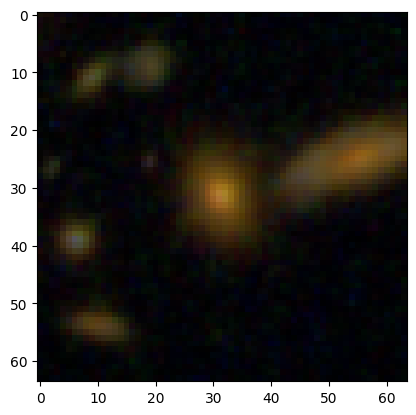

In [10]:
im, lab = dataset_tr[5]
plt.imshow(im.permute(1,2,0))

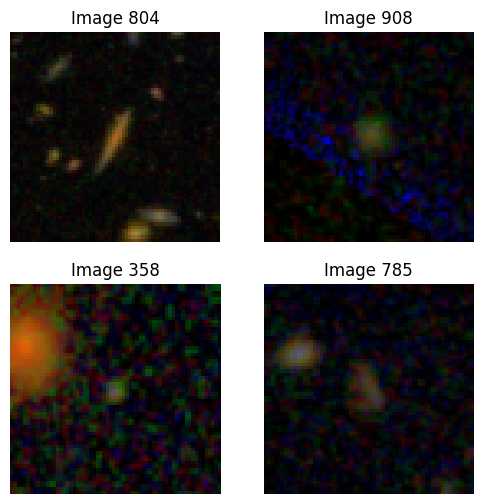

In [11]:
from ml_sandbox.dataset import show_sample_images
for i in range(3,4):
    show_sample_images(dataset_tr, num_images=i+1)

# training

In [12]:
catalog['merging-candels_merger'].max()+1

np.float64(59.0)

In [13]:
from ml_sandbox.models import SimpleCNNClassifier
from ml_sandbox.train_eval import train_cnn, test_cnn
from ml_sandbox.dataset import get_dataloader
from sklearn.model_selection import train_test_split

model = SimpleCNNClassifier(num_classes=int(catalog['merging-candels_merger'].max()+1), input_channels=3)

train_cat, test_cat = train_test_split(catalog, test_size=0.2, random_state=42)

train_dataset = get_dataset(train_cat, label_cols=['merging-candels_merger'], size=None, train=True, dir='.tmp/')
test_dataset = get_dataset(test_cat, label_cols=['merging-candels_merger'], size=None, train=False, dir='.tmp/')

train_loader = get_dataloader(train_dataset, batch_size=8)
test_loader = get_dataloader(test_dataset, batch_size=8)

from torch.nn import CrossEntropyLoss
criterion = CrossEntropyLoss()

from torch.optim import Adam
optimizer = Adam(model.parameters(), lr=1e-3)

In [14]:
for images, labels in train_loader:
    print(images.shape, labels.shape)
    print(labels.dim())
    break

torch.Size([8, 3, 64, 64]) torch.Size([8])
1


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)
device

device(type='cuda')

In [16]:
hist = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

do_cnn_training = False
if do_cnn_training:
    for i in range(5):
        train_loss, train_acc = train_cnn(train_loader, model, criterion, optimizer, device=device) 
        test_loss, test_acc = test_cnn(test_loader, model, criterion, device=device)
        hist['train_loss'].append(train_loss)
        hist['train_acc'].append(train_acc)
        hist['test_loss'].append(test_loss)
        hist['test_acc'].append(test_acc)
        print(f"Epoch: {i+1}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

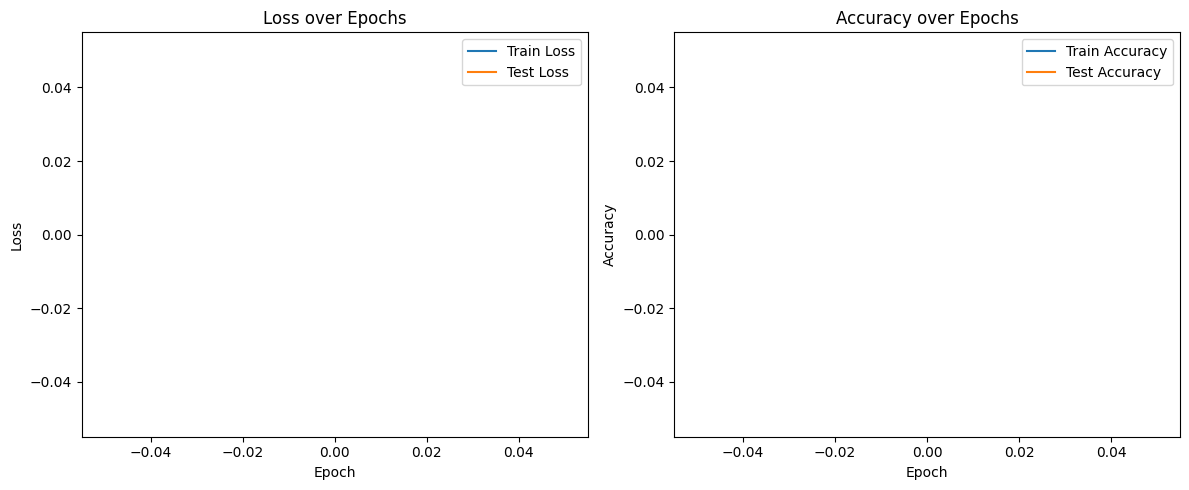

In [17]:
from ml_sandbox.train_eval import plot_training_history
plot_training_history(hist)

In [18]:
from ml_sandbox.models import make_pca_rf_pipeline
model_skl = make_pca_rf_pipeline(n_pca_comp=150, n_trees=100, random_state=42)


In [25]:
def test_convert_ds(dataset, batch_size=32, num_workers=None):
    """
    Convert a torch-style dataset to (X, y) using parallel workers.

    Uses a PyTorch `DataLoader` with `num_workers` to parallelize item loading
    and transforms. This avoids pickling the whole dataset object for
    multiprocessing and leverages DataLoader's worker pool.
    """
    import numpy as np
    from torch.utils.data import DataLoader
    import multiprocessing

    if num_workers is None:
        num_workers = min(4, multiprocessing.cpu_count())

    def collate_fn(batch):
        imgs = [b[0].cpu().numpy().ravel() for b in batch]
        labels = [int(b[1].item()) if hasattr(b[1], "item") else int(b[1]) for b in batch]
        return np.stack(imgs), np.array(labels, dtype=int)

    loader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers, collate_fn=collate_fn)

    X_parts = []
    y_parts = []
    for Xb, yb in loader:
        X_parts.append(Xb)
        y_parts.append(yb)

    if len(X_parts) == 0:
        return np.empty((0,)), np.empty((0,))

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    return X, y


In [ ]:
# X_train, y_train = test_convert_ds(train_dataset)
# X_test, y_test = test_convert_ds(test_dataset)


In [ ]:
from ml_sandbox.dataset import convert_dataset_sklearn
X_train, y_train = convert_dataset_sklearn(train_dataset)
X_test, y_test = convert_dataset_sklearn(test_dataset)


NameError: name 'x' is not defined

In [ ]:
model_skl.fit(X_train, y_train)
test_accuracy = model_skl.score(X_test, y_test)
print(f'Test Accuracy: {test_accuracy:.4f}')
